# Classifier Training

Train a classifier (ML) to detect familiar/unfamiliar face viewing based on ERP component statistical features.  

Classifiers to test:
- Support Vector Machine (SVM) 
- K Nearest Neighbors (KNN)
- Logistic Regression (strong baseline)
- Random Forest
- Convolutional Neural Network (CNN) *massive datasets are preferred*
- Recurrent Neural Network (RNN) *massive datasets are preferred*

## 1. Load and Preprocess Data

In [20]:
## Imports
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split

### Load Data

Load csv data with extracted features.

In [60]:
## Load data
data_dir = 'Experiment Data/'
file_name = 'erp_epoch_features.csv'

data = pd.read_csv(data_dir + file_name)

In [61]:
## Data info
print("ERP Feature Data Info:")
print(data.info())
print(data.head())

ERP Feature Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 46 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   condition    82 non-null     object 
 1   T8_mean      82 non-null     float64
 2   T8_median    82 non-null     float64
 3   T8_max       82 non-null     float64
 4   T8_min       82 non-null     float64
 5   T8_ptp       82 non-null     float64
 6   T8_std       82 non-null     float64
 7   T8_skew      82 non-null     float64
 8   T8_auc       82 non-null     float64
 9   T8_kurtosis  82 non-null     float64
 10  P7_mean      82 non-null     float64
 11  P7_median    82 non-null     float64
 12  P7_max       82 non-null     float64
 13  P7_min       82 non-null     float64
 14  P7_ptp       82 non-null     float64
 15  P7_std       82 non-null     float64
 16  P7_skew      82 non-null     float64
 17  P7_auc       82 non-null     float64
 18  P7_kurtosis  82 non-null     

### Preprocessing

1. Re-label class labels (0 for familiar, 1 for unfamiliar) and remove 'move' types 
2. Remove outliers (if any)
3. Scale/normalize (StandardScaler)

In [62]:
## Relablel class labels
# Filter out 'Mov' rows first
data = data[data['condition'].isin(['Fam', 'Unf'])]

# Map string labels to binary (0 - familiar, 1 - unfamiliar)
data['condition'] = data['condition'].map({'Fam': 0, 'Unf': 1})
data = data.rename(columns={'condition': 'IS_UNFAMILIAR'})

print("Relabeled ERP Feature Data Info:")
print(data.head())

Relabeled ERP Feature Data Info:
   IS_UNFAMILIAR     T8_mean   T8_median      T8_max     T8_min      T8_ptp  \
3              0   46.954099   50.347313   56.937373  22.308461   34.628913   
4              1  -36.872840  -35.201276  -21.245172 -63.531115   42.285943   
5              0  -10.705244  -14.069042   13.298647 -27.201278   40.499925   
6              1    7.513957    5.286256   44.518249 -34.205608   78.723857   
7              1  141.677710  133.974208  252.728845  69.707297  183.021548   

      T8_std   T8_skew     T8_auc  T8_kurtosis  ...  O2_kurtosis    Cz_mean  \
3   9.139291 -1.587969   4.737309     4.826802  ...     4.445543 -28.177790   
4  11.430023 -0.834420  -3.729159     3.100154  ...     2.279664  -3.538275   
5  10.799371  0.718492  -1.104269     2.795968  ...     3.013305   4.750187   
6  21.453038 -0.198430   0.759232     2.948116  ...     1.561626  10.050233   
7  48.105059  0.640325  14.033476     2.797042  ...     1.598026  -2.775386   

   Cz_median     

In [63]:
## Prepare data
X = data.drop(columns=['IS_UNFAMILIAR'])
y = data['IS_UNFAMILIAR']

# Currently using all data for training due to limited dataset size
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0, random_state=42)
X_train, y_train = X, y 

In [64]:
## Scale features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

print("Scaled ERP Feature Data Info:")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

Scaled ERP Feature Data Info:
    T8_mean  T8_median    T8_max    T8_min    T8_ptp    T8_std   T8_skew  \
0  2.159751   2.376239  1.339639  1.857082 -0.176140 -0.251120 -2.477786   
1 -1.288133  -1.240345 -1.090566 -1.502181  0.133450  0.075378 -1.326676   
2 -0.211834  -0.346976 -0.016816 -0.080442  0.061238 -0.014508  1.045529   
3  0.537539   0.471274  0.953606 -0.354551  1.606716  1.503960 -0.355148   
4  6.055825   5.911583  7.425566  3.711997  5.823702  5.302677  0.926121   

     T8_auc  T8_kurtosis   P7_mean  ...  O2_kurtosis   Cz_mean  Cz_median  \
0  2.185443     2.334827 -0.774841  ...     1.666240 -0.652430  -0.594399   
1 -1.309050     0.472507  1.202189  ...    -0.244012  0.538770   0.631310   
2 -0.225640     0.144420  0.671539  ...     0.403041  0.939476   0.973498   
3  0.543511     0.308523  0.648253  ...    -0.877304  1.195707   1.382433   
4  6.022390     0.145578  1.882798  ...    -0.845200  0.575652   0.873044   

     Cz_max    Cz_min    Cz_ptp    Cz_std   Cz_ske

## 2. SVM Classifier

Build an SVM classifier, evaluate training accuracy, and identify contribution from different features. 

Look for the channels with the greatest impact, and observe the effect for removing certain channels.

In [136]:
## Imports
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay, permutation_importance

### Train Initial SVM

In [195]:
## Train and evaluate SVM
# Params:
# kernel: rbf (default), linear, poly, sigmoid
# C (regularization parameter): default=1.0

svm = SVC(kernel='rbf', C=1, random_state=42)
svm.fit(X_train_scaled, y_train)

# Evaluate
train_accuracy = svm.score(X_train_scaled, y_train)
# test_accuracy = svm.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.3f}")
# print(f"Test Accuracy: {test_accuracy:.3f}")

# Cross-validation for more robust estimate (folds data 10 times)
cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=10)
print(f"CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

Training Accuracy: 0.861
CV Accuracy: 0.602 (+/- 0.437)


Training Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86        40
           1       0.87      0.85      0.86        39

    accuracy                           0.86        79
   macro avg       0.86      0.86      0.86        79
weighted avg       0.86      0.86      0.86        79

Training Confusion Matrix:


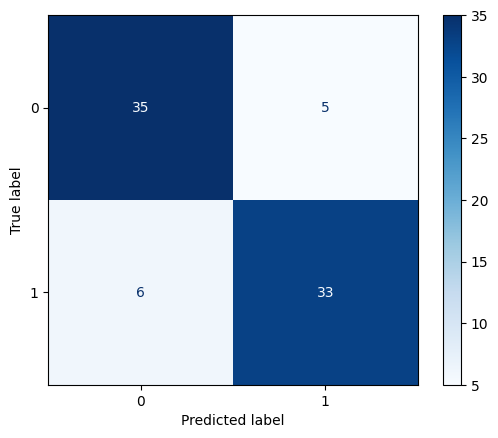

In [67]:
## Classification Report & Confusion Matrix
y_train_pred = svm.predict(X_train_scaled)
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))

print("Training Confusion Matrix:")
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

### Plot Decision Boundary for Different Kernels

Use PCA to represent the data in the two major components. 

Then, train SVC model and plot decision boundaries. Identify which kernel has the best performance.

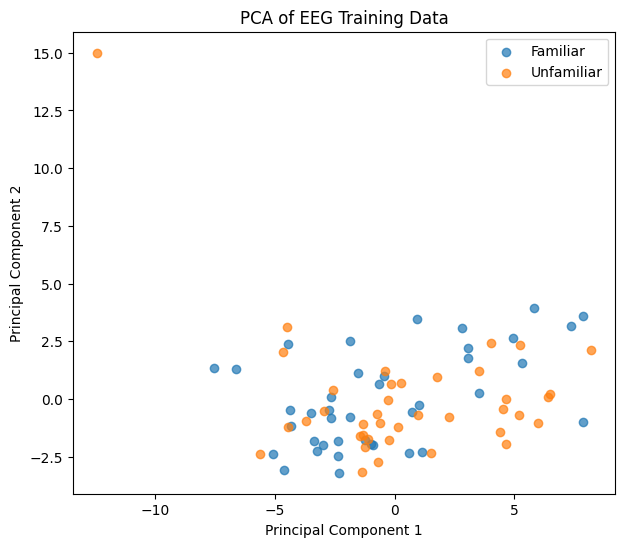

In [178]:
## PCA to 2D for visualization 
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Plot PCA results
plt.figure(figsize=(7, 6))
class_labels = ['Familiar', 'Unfamiliar']
for label in np.unique(y_train):
    plt.scatter(X_train_pca[y_train == label, 0], X_train_pca[y_train == label, 1], label=class_labels[label], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of EEG Training Data')
plt.legend()
plt.show()

In [100]:
## Function to plot decision boundaries
def plot_training_data_with_decision_boundary(
    kernel, ax=None, long_title=True, support_vectors=True
):
    # Train the SVC
    clf = SVC(kernel=kernel, gamma=2).fit(X_train_pca, y_train)

    # Settings for plotting
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))
    x_min, x_max, y_min, y_max = -10, 10, -5, 5
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

    # Plot decision boundary and margins
    common_params = {"estimator": clf, "X": X_train_pca, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )

    if support_vectors:
        # Plot bigger circles around samples that serve as support vectors
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=150,
            facecolors="none",
            edgecolors="k",
        )

    # Plot samples by color and add legend
    scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=30, edgecolors="k")
    ax.legend(*scatter.legend_elements(), loc="upper right", title="IS_UNFAMILIAR")
    if long_title:
        ax.set_title(f" Decision boundaries of {kernel} kernel in SVC")
    else:
        ax.set_title(kernel)

    if ax is None:
        plt.show()
        
    # Classifier accuracy info
    y_train_pred = clf.predict(X_train_pca)
    print(f"{kernel} Kernel Training Accuracy: {accuracy_score(y_train, y_train_pred):.3f}")
    # Number of correct predictions
    correct_predictions = (y_train == y_train_pred).sum()
    print(f"Number of correct predictions: {correct_predictions} out of {len(y_train)}")

linear Kernel Training Accuracy: 0.544
Number of correct predictions: 43 out of 79


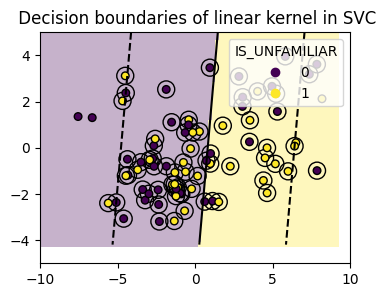

In [101]:
plot_training_data_with_decision_boundary("linear")

poly Kernel Training Accuracy: 0.608
Number of correct predictions: 48 out of 79


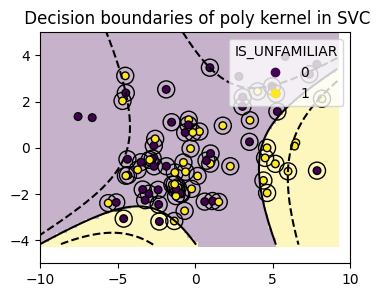

In [102]:
plot_training_data_with_decision_boundary("poly")

rbf Kernel Training Accuracy: 0.886
Number of correct predictions: 70 out of 79


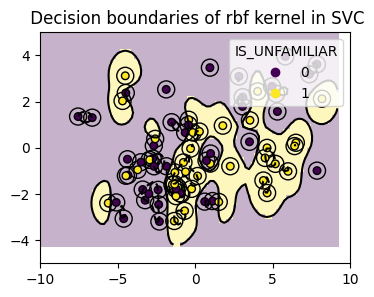

In [103]:
plot_training_data_with_decision_boundary("rbf")

sigmoid Kernel Training Accuracy: 0.430
Number of correct predictions: 34 out of 79


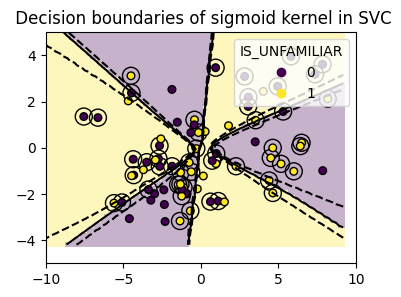

In [104]:
plot_training_data_with_decision_boundary("sigmoid")

Based on these results, rbf is most well-suited for the decision in this task. Although, it could be overfitting.

### Evaluate Feature Importance

In [148]:
## Feature importance analysis
# Calculate permutation importance
perm = permutation_importance(svm, X_train_scaled, y_train, n_repeats=30, random_state=42)
df = pd.DataFrame({'feature': X_train.columns, 'importance': perm.importances_mean})
df['channel'] = df['feature'].str.split('_').str[0]
df['stat'] = df['feature'].str.split('_').str[1]

# Top features with 1-based ranks as the index (no duplicate numbering)
num_features = 20
topN = df.sort_values('importance', ascending=False).head(num_features).reset_index(drop=True)
topN.index = np.arange(1, len(topN) + 1)
topN.index.name = ''
print(f"Top {num_features} Features:")
print(topN[['feature', 'importance']])

# Channel importance
print("\nChannel Importance:")
print(df.groupby('channel')['importance'].sum().sort_values(ascending=False))

# Statistical feature importance
print("\nStatistical Feature Importance:")
print(df.groupby('stat')['importance'].sum().sort_values(ascending=False))

# N250 vs P300
n250 = df[df['channel'].isin(['T8', 'P7', 'P8', 'O2'])]['importance'].sum()
p300 = df[df['channel'] == 'Cz']['importance'].sum()
print(f"\nN250 (T8,P7,P8,O2): {n250:.4f}")
print(f"P300 (Cz): {p300:.4f}")

Top 20 Features:
        feature  importance
                           
1   Cz_kurtosis    0.017300
2        T8_max    0.016878
3        Cz_min    0.015612
4       O2_skew    0.014768
5        Cz_ptp    0.013924
6        Cz_std    0.013924
7        T8_std    0.013924
8       Cz_skew    0.013502
9        T8_ptp    0.012658
10       T8_auc    0.010970
11      T8_mean    0.009705
12       Cz_max    0.008439
13  P8_kurtosis    0.007173
14      P8_skew    0.006751
15  O2_kurtosis    0.006329
16    T8_median    0.005485
17       P7_ptp    0.005063
18       P7_std    0.004641
19       O2_max    0.004641
20       O2_ptp    0.004641

Channel Importance:
channel
Cz    0.077637
T8    0.071308
O2    0.010970
P8    0.002110
P7   -0.039241
Name: importance, dtype: float64

Statistical Feature Importance:
stat
std         0.036287
ptp         0.030380
kurtosis    0.028270
skew        0.025738
max         0.018143
min         0.003376
mean       -0.002110
auc        -0.008017
median     -0.009283
Nam

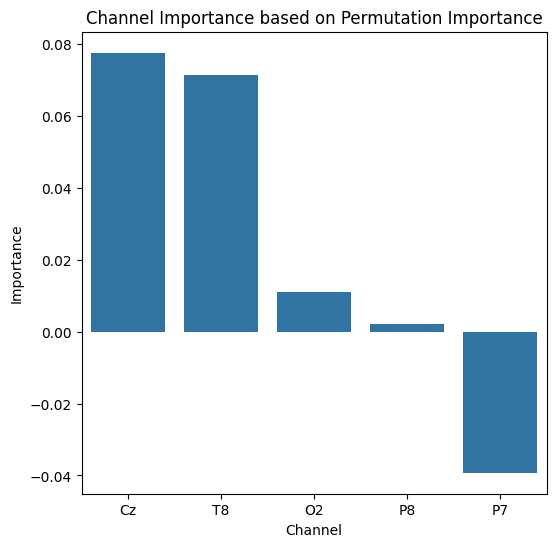

In [141]:
## Plot channel importances
import seaborn as sns
channel_importance = df.groupby('channel')['importance'].sum().sort_values(ascending=False)
plt.figure(figsize=(6, 6))
sns.barplot(x=channel_importance.index, y=channel_importance.values)
plt.title('Channel Importance based on Permutation Importance')
plt.xlabel('Channel')
plt.ylabel('Importance')
plt.show()

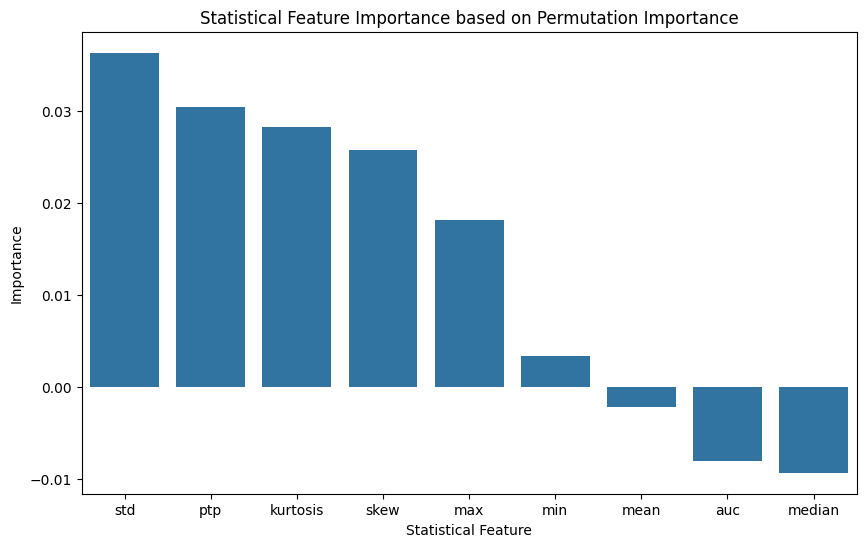

In [142]:
## Plot statistical feature importances
stat_importance = df.groupby('stat')['importance'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=stat_importance.index, y=stat_importance.values)
plt.title('Statistical Feature Importance based on Permutation Importance')
plt.xlabel('Statistical Feature')
plt.ylabel('Importance')
plt.show()

### Re-train WITHOUT P7

In [150]:
## Remove P7 features from dataset
X_train_reduced = X_train.drop(columns=[col for col in X_train.columns if col.startswith('P7_')])
print(f"Reduced feature set shape (removed P7 features): {X_train_reduced.shape}")

Reduced feature set shape (removed P7 features): (79, 36)


In [151]:
## Re-scale reduced dataset
scaler_reduced = StandardScaler()
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
print("Scaled Reduced ERP Feature Data Info:")
print(pd.DataFrame(X_train_reduced_scaled, columns=X_train_reduced.columns).head())

Scaled Reduced ERP Feature Data Info:
    T8_mean  T8_median    T8_max    T8_min    T8_ptp    T8_std   T8_skew  \
0  2.159751   2.376239  1.339639  1.857082 -0.176140 -0.251120 -2.477786   
1 -1.288133  -1.240345 -1.090566 -1.502181  0.133450  0.075378 -1.326676   
2 -0.211834  -0.346976 -0.016816 -0.080442  0.061238 -0.014508  1.045529   
3  0.537539   0.471274  0.953606 -0.354551  1.606716  1.503960 -0.355148   
4  6.055825   5.911583  7.425566  3.711997  5.823702  5.302677  0.926121   

     T8_auc  T8_kurtosis   P8_mean  ...  O2_kurtosis   Cz_mean  Cz_median  \
0  2.185443     2.334827  1.426052  ...     1.666240 -0.652430  -0.594399   
1 -1.309050     0.472507  0.842487  ...    -0.244012  0.538770   0.631310   
2 -0.225640     0.144420  0.918679  ...     0.403041  0.939476   0.973498   
3  0.543511     0.308523  0.305489  ...    -0.877304  1.195707   1.382433   
4  6.022390     0.145578 -2.062208  ...    -0.845200  0.575652   0.873044   

     Cz_max    Cz_min    Cz_ptp    Cz_std 

In [197]:
## Train and evaluate SVM
# Params:
# kernel: rbf (default), linear, poly, sigmoid
# C (regularization parameter): default=1.0

svm_reduced = SVC(kernel='rbf', C=1, random_state=42)
svm_reduced.fit(X_train_reduced_scaled, y_train)

# Evaluate
train_accuracy = svm_reduced.score(X_train_reduced_scaled, y_train)
# test_accuracy = svm_reduced.score(X_test_reduced_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.3f}")
# print(f"Test Accuracy: {test_accuracy:.3f}")

# Cross-validation for more robu##########33dcdsvd33###st estimate (folds data 5 times)
cv_scores = cross_val_score(svm_reduced, X_train_reduced_scaled, y_train, cv=10)
print(f"CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

Training Accuracy: 0.886
CV Accuracy: 0.579 (+/- 0.395)


Training Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        40
           1       0.88      0.90      0.89        39

    accuracy                           0.89        79
   macro avg       0.89      0.89      0.89        79
weighted avg       0.89      0.89      0.89        79

Training Confusion Matrix:


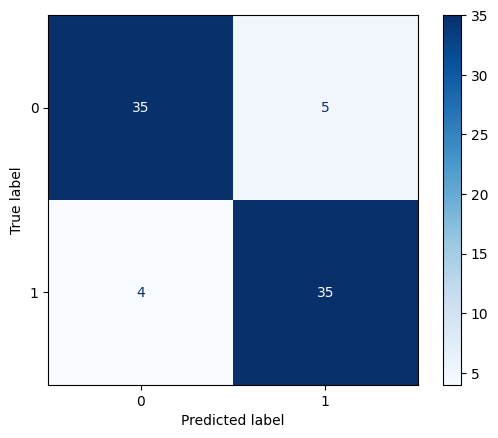

In [155]:
## Classification Report & Confusion Matrix
y_train_pred = svm_reduced.predict(X_train_reduced_scaled)
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))

print("Training Confusion Matrix:")
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_reduced.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

#### PCA Decision Boundary Check

Re-perform PCA decision boundary check with reduced model

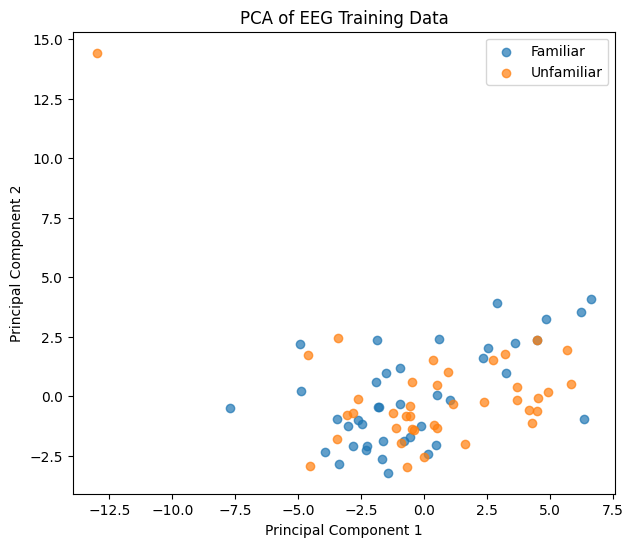

In [187]:
## PCA to 2D for visualization 
pca = PCA(n_components=2)
X_train_reduced_pca = pca.fit_transform(X_train_reduced_scaled)

# Plot PCA results
plt.figure(figsize=(7, 6))
class_labels = ['Familiar', 'Unfamiliar']
for label in np.unique(y_train):
    plt.scatter(X_train_reduced_pca[y_train == label, 0], X_train_reduced_pca[y_train == label, 1], label=class_labels[label], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of EEG Training Data')
plt.legend()
plt.show()

In [182]:
## Function to plot decision boundaries
def plot_training_data_with_decision_boundary(
    kernel, ax=None, long_title=True, support_vectors=True
):
    # Train the SVC
    clf = SVC(kernel=kernel, gamma=2).fit(X_train_reduced_pca, y_train)

    # Settings for plotting
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))
    x_min, x_max, y_min, y_max = -10, 10, -5, 5
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

    # Plot decision boundary and margins
    common_params = {"estimator": clf, "X": X_train_reduced_pca, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )

    if support_vectors:
        # Plot bigger circles around samples that serve as support vectors
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=150,
            facecolors="none",
            edgecolors="k",
        )

    # Plot samples by color and add legend
    scatter = ax.scatter(X_train_reduced_pca[:, 0], X_train_reduced_pca[:, 1], c=y_train, s=30, edgecolors="k")
    ax.legend(*scatter.legend_elements(), loc="upper right", title="IS_UNFAMILIAR")
    if long_title:
        ax.set_title(f" Decision boundaries of {kernel} kernel in SVC")
    else:
        ax.set_title(kernel)

    if ax is None:
        plt.show()
        
    # Classifier accuracy info
    y_train_pred = clf.predict(X_train_reduced_pca)
    print(f"{kernel} Kernel Training Accuracy: {accuracy_score(y_train, y_train_pred):.3f}")
    # Number of correct predictions
    correct_predictions = (y_train == y_train_pred).sum()
    print(f"Number of correct predictions: {correct_predictions} out of {len(y_train)}")

linear Kernel Training Accuracy: 0.570
Number of correct predictions: 45 out of 79


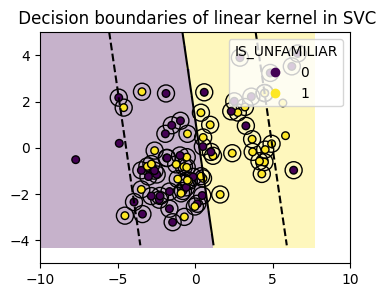

In [183]:
plot_training_data_with_decision_boundary("linear")

poly Kernel Training Accuracy: 0.620
Number of correct predictions: 49 out of 79


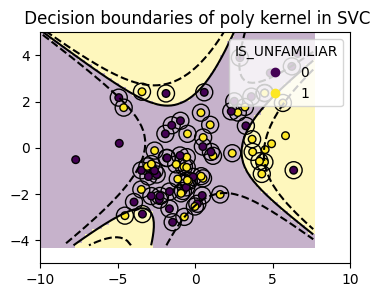

In [184]:
plot_training_data_with_decision_boundary("poly")

rbf Kernel Training Accuracy: 0.886
Number of correct predictions: 70 out of 79


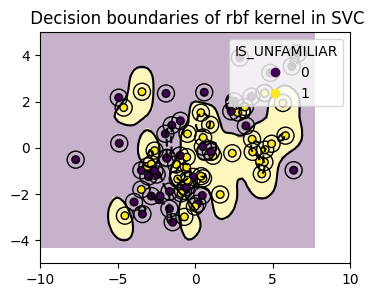

In [185]:
plot_training_data_with_decision_boundary("rbf")

sigmoid Kernel Training Accuracy: 0.582
Number of correct predictions: 46 out of 79


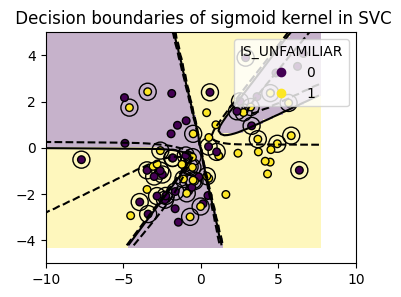

In [186]:
plot_training_data_with_decision_boundary("sigmoid")

Sigmoid performed better than regular, but otherwise the results were very similar for the components. This makes sense, since the major components would not have heavily included features with low contribution.

## 3. Other Model Exploration

In [200]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [201]:
## Common evaluation function
def eval_model(name, model, X, y):
    model.fit(X, y)
    print(f"{name} Train Acc: {model.score(X, y):.3f}")
    cv = cross_val_score(model, X, y, cv=10)
    print(f"{name} CV: {cv.mean():.3f} (+/- {cv.std()*2:.3f})")
    y_pred = model.predict(X)
    print(classification_report(y, y_pred))
    ConfusionMatrixDisplay(confusion_matrix(y, y_pred)).plot(cmap=plt.cm.Blues)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

### 3.1 K-Nearest Neighbors (KNN)

KNN (Full) Train Acc: 0.722
KNN (Full) CV: 0.577 (+/- 0.470)
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        40
           1       0.71      0.74      0.72        39

    accuracy                           0.72        79
   macro avg       0.72      0.72      0.72        79
weighted avg       0.72      0.72      0.72        79



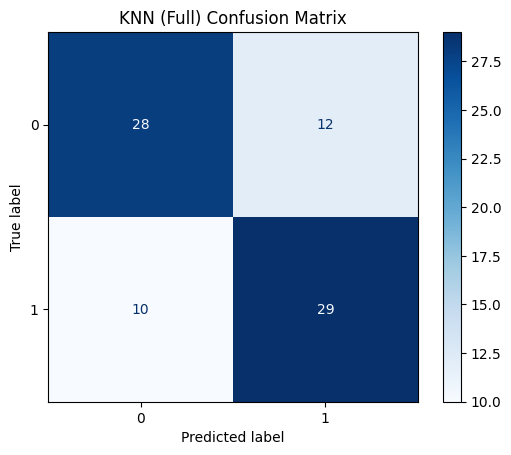

KNN (Reduced) Train Acc: 0.823
KNN (Reduced) CV: 0.641 (+/- 0.287)
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        40
           1       0.80      0.85      0.82        39

    accuracy                           0.82        79
   macro avg       0.82      0.82      0.82        79
weighted avg       0.82      0.82      0.82        79



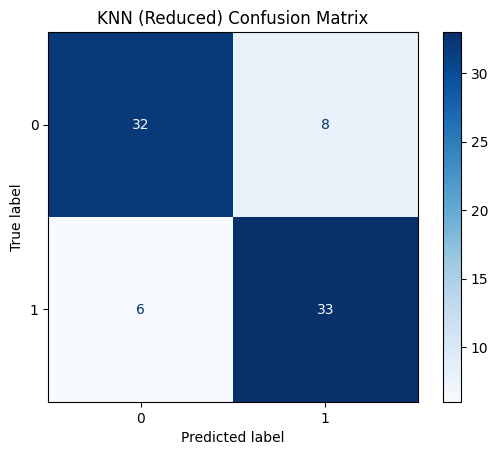

In [202]:
# Train KNN Classifier

# Full dataset
eval_model("KNN (Full)", KNeighborsClassifier(n_neighbors=5), X_train_scaled, y_train)
# Reduced dataset
eval_model("KNN (Reduced)", KNeighborsClassifier(n_neighbors=5), X_train_reduced_scaled, y_train)

### 3.2 Logistic Regression

LogReg (Full) Train Acc: 0.722
LogReg (Full) CV: 0.568 (+/- 0.457)
              precision    recall  f1-score   support

           0       0.76      0.65      0.70        40
           1       0.69      0.79      0.74        39

    accuracy                           0.72        79
   macro avg       0.73      0.72      0.72        79
weighted avg       0.73      0.72      0.72        79



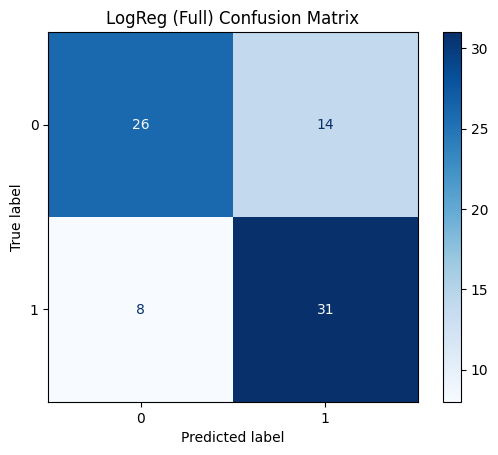

LogReg (Reduced) Train Acc: 0.684
LogReg (Reduced) CV: 0.516 (+/- 0.401)
              precision    recall  f1-score   support

           0       0.70      0.65      0.68        40
           1       0.67      0.72      0.69        39

    accuracy                           0.68        79
   macro avg       0.68      0.68      0.68        79
weighted avg       0.68      0.68      0.68        79



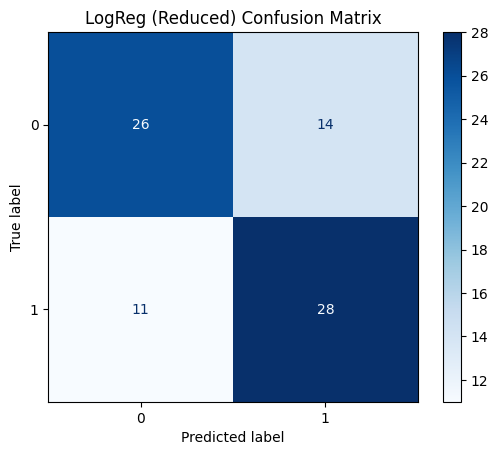

In [ ]:
## Train Logistic Regression Classifier

# Full dataset
eval_model("LogReg (Full)", LogisticRegression(max_iter=100, solver='liblinear', random_state=42), X_train_scaled, y_train)
# Reduced dataset
eval_model("LogReg (Reduced)", LogisticRegression(max_iter=1000, solver='liblinear', random_state=42), X_train_reduced_scaled, y_train)

### 3.3 Random Forest

RF (Full) Train Acc: 1.000
RF (Full) CV: 0.502 (+/- 0.328)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        39

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



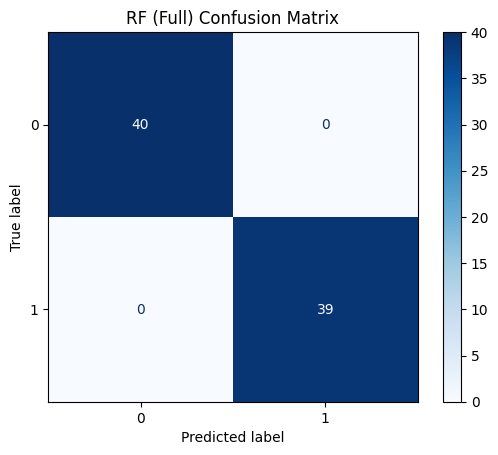

RF (Reduced) Train Acc: 1.000
RF (Reduced) CV: 0.530 (+/- 0.234)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        39

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



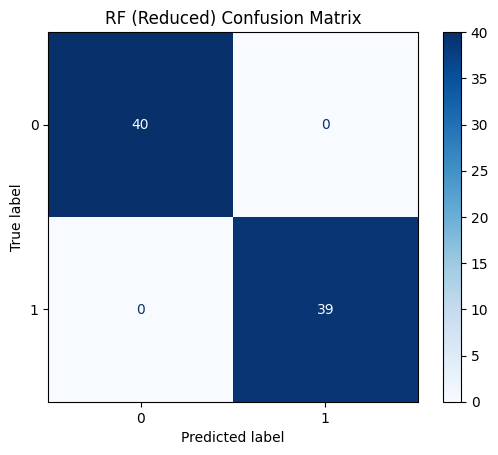

In [212]:
## Train Random Forest Classifier

# Full dataset
eval_model("RF (Full)", RandomForestClassifier(n_estimators=25, random_state=42, n_jobs=-1), X_train_scaled, y_train)
# Reduced dataset
eval_model("RF (Reduced)", RandomForestClassifier(n_estimators=25, random_state=42, n_jobs=-1), X_train_reduced_scaled, y_train)